In [5]:
import pmlb
summ = pmlb.dataset_lists.df_summary
summ

,dataset,n_instances,n_features,n_binary_features,n_categorical_features,n_continuous_features,endpoint_type,n_classes,imbalance,task
0,1027_ESL,488,4,0,0,4,continuous,9.0,0.099363,regression
1,1028_SWD,1000,10,0,0,10,continuous,4.0,0.108291,regression
2,1029_LEV,1000,4,0,0,4,continuous,5.0,0.111245,regression
3,1030_ERA,1000,4,0,0,4,continuous,9.0,0.031251,regression
4,1089_USCrime,47,13,0,0,13,continuous,42.0,0.002970,regression
...,...,...,...,...,...,...,...,...,...,...
279,wine_quality_red,1599,11,0,0,11,categorical,6.0,0.228804,classification
280,wine_quality_white,4898,11,0,0,11,categorical,7.0,0.211974,classification
281,wine_recognition,178,13,0,2,11,categorical,3.0,0.012530,classification
282,xd6,973,9,9,0,0,categorical,2.0,0.114332,classification


In [17]:
import numpy as np

def uniform_sampling_2D(x, y, num_samples):
    # Combine x and y into a 2D array
    points = np.vstack((x, y)).T

    # Apply log transformation to the x values

    # Normalize log_x to get probabilities
    probabilities = x / np.sum(x)

    # Use the probabilities to sample point indices
    indices = np.random.choice(np.arange(points.shape[0]), size=num_samples, p=probabilities)

    # Get the sampled points
    samples = points[indices]

    return samples



In [45]:
log_x = np.log(summ['n_instances']) / np.log(10)
log_y = np.log(summ['n_features']) / np.log(10)
samples = uniform_sampling_2D(log_x, log_y, 14)

In [55]:
import json
choices = json.load(open('choice_tasks_v2.json'))
dataset_names = [c['dataset'] for c in choices]
selected_sets = summ[summ['dataset'].isin(dataset_names)]
selected_dots = selected_sets[['n_instances', 'n_features']].values

In [56]:
samples = np.log(selected_dots) / np.log(10)

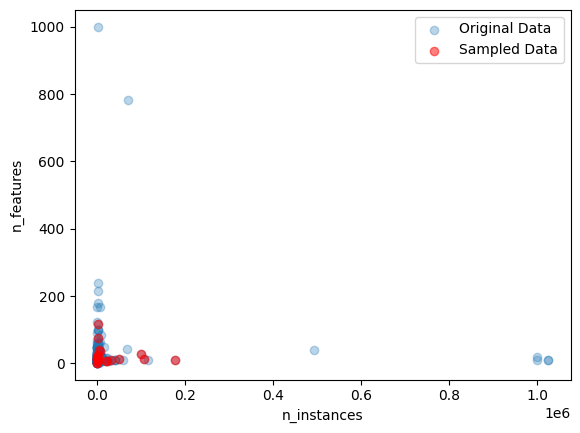

Bad pipe message: %s [b'\x03#\xbeI\xe0\x94}\xb5\xf5X%\x08\x14\xf9_p\x9a\x94\x00\x00|\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0]\xc0a\xc0W\xc0S\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0\xa2\xc0\x9e\xc0\\\xc0`\xc0V\xc0']
Bad pipe message: %s [b"$\xc0(\x00k\x00j\xc0#\xc0'\x00g\x00@\xc0\n\xc0\x14\x009\x008\xc0\t\xc0\x13\x003\x002\x00\x9d\xc0\xa1\xc0\x9d\xc0Q\x00\x9c\xc0\xa0\xc0\x9c\xc0P\x00=\x00<\x005\x00/\x00\x9a\x00\x99\xc0\x07\xc0\x11\x00\x96\x00\x05\x00\xff\x01\x00\x00j\x00\x00\x00\x0e\x00\x0c\x00\x00"]
Bad pipe message: %s [b"O\x8fE\xc3w\x93\x892\xa3\xb4\xe7\xc8\xa8T<\x92\xebb\x00\x00\xa6\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0]\xc0a\xc0W\xc0S\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0\xa2\xc0\x9e\xc0\\\xc0`\xc0V\xc0R\xc0$\xc0(\x00k\x00j\xc0s\xc0w\x00\xc4\x00\xc3\xc0#\xc0'\x00g\x00@\xc0r\xc0v\x00\xbe\x00\xbd\xc0\n\xc0\x14\x009\x008\x00\x88\x00\x87\xc0\t\xc0\x13\x003\x002\x00\x9a\x00\x99\x0

In [62]:
x = summ['n_instances']
y = summ['n_features']
from matplotlib import pyplot as plt
plt.scatter(x, y, alpha=0.3, label='Original Data')

# Plot sampled data in red
plt.scatter(10 ** samples[:, 0], 10 ** samples[:, 1], color='red', alpha=0.5, label='Sampled Data')

plt.legend()
plt.xlabel('n_instances')
plt.ylabel('n_features')

plt.savefig('images/sampled_in_original.svg')

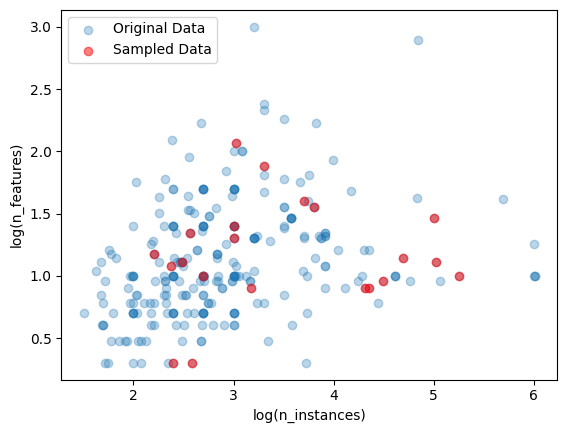

In [61]:
from matplotlib import pyplot as plt
plt.scatter(log_x, log_y, alpha=0.3, label='Original Data')

# Plot sampled data in red
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, label='Sampled Data')

plt.legend()
plt.xlabel('log(n_instances)')
plt.ylabel('log(n_features)')

plt.savefig('images/sampled_in_log.svg')